# GreenPEFT — Surrogate Audit (Kaggle)

**Section 32 of the GreenPEFT Agent Work Specification** executed on Kaggle with a fresh training + GroupKFold validation run, since the original `.joblib` is not available in this environment.

All provenance rules from spec sections 3.1–3.5 are respected:

- `config_id` is used as the GroupKFold group key
- Energy model is trained only on `energy_measurement_valid == 1`
- Carbon is treated as derived (`energy_kwh × 0.65`), never modeled independently
- Target-derived columns are excluded from the feature matrix
- `scale_reference` and `context_only` rows are excluded from surrogate fitting

**Tasks covered:** A (repo inspect → adapted), B (joblib inspect → adapted to fresh training), C (feature list), D (target models), E (GroupKFold validation), F (`cv_metrics.csv`), G (OOF predictions), H (actual-vs-predicted plots), I (surrogate status report).

In [1]:
# ============================================================
# GreenPEFT — Surrogate Audit (Section 32: Tasks A–I)
# Fresh training + GroupKFold validation on Kaggle
# ============================================================
import os, glob, json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

OUT_ROOT = Path("/kaggle/working/greenpeft")
(OUT_ROOT / "models").mkdir(parents=True, exist_ok=True)
(OUT_ROOT / "results" / "surrogate").mkdir(parents=True, exist_ok=True)
(OUT_ROOT / "results" / "figures").mkdir(parents=True, exist_ok=True)

print("Output root:", OUT_ROOT)

Output root: /kaggle/working/greenpeft


In [2]:
# ============================================================
# Task A/B adapted: locate dataset (no prior .joblib available on Kaggle)
# ============================================================
candidates = [
    "/kaggle/input/datasets/ashrafulislamtanzil/"
    "greenpeft-surrogate-data/greenpeft_ml_ready_dataset.csv",
] + glob.glob("/kaggle/input/**/greenpeft_ml_ready_dataset.csv", recursive=True)

DATA_PATH = next((p for p in candidates if os.path.exists(p)), None)
assert DATA_PATH, "Attach the greenpeft-surrogate-data Kaggle Dataset first."
print("Loading:", DATA_PATH)

raw = pd.read_csv(DATA_PATH)
print("Raw shape:", raw.shape)

# Split by provenance — do NOT mix roles
peft_train = raw[raw["analysis_role"] == "surrogate_train"].copy()
scale_ref  = raw[raw["analysis_role"] == "scale_reference"].copy()
context    = raw[raw["analysis_role"] == "context_only"].copy()

print(f"\nsurrogate_train : {len(peft_train)} rows  ({peft_train['config_id'].nunique()} unique configs)")
print(f"scale_reference : {len(scale_ref)} rows")
print(f"context_only    : {len(context)} rows")

print("\nmeasurement_pass breakdown within surrogate_train:")
print(peft_train["measurement_pass"].value_counts())

print("\nenergy_measurement_valid crosstab:")
print(pd.crosstab(peft_train["measurement_pass"],
                  peft_train["energy_measurement_valid"]))

Loading: /kaggle/input/datasets/ashrafulislamtanzil/greenpeft-surrogate-data/greenpeft_ml_ready_dataset.csv
Raw shape: (477, 46)

surrogate_train : 82 rows  (41 unique configs)
scale_reference : 369 rows
context_only    : 26 rows

measurement_pass breakdown within surrogate_train:
measurement_pass
original      41
remeasured    41
Name: count, dtype: int64

energy_measurement_valid crosstab:
energy_measurement_valid   0   1
measurement_pass                
original                   0  41
remeasured                41   0


In [3]:
# ============================================================
# Task C: Pre-run feature list  (knowable BEFORE training starts)
# ============================================================
FEATURES_NUMERIC = [
    # scale / architecture
    "params_b", "log_params_b",
    # method / adapter
    "rank", "log1p_rank", "is_adapter_method", "is_full_finetune",
    "has_adapter_config", "adapter_capacity",
    # quantisation
    "quant_bits", "is_quantized", "params_x_bits", "log_params_x_bits",
    # memory proxies (deterministic from scale + method + gpu)
    "weight_bytes_gb", "trainable_frac", "trainable_params_b",
    "optimizer_state_gb", "gradient_gb", "memory_proxy_gb",
    "vram_pressure", "gpu_total_gb", "gpu_budget_known",
]
FEATURES_CAT = ["method", "backbone", "family"]

# Task D: Targets
TARGETS = ["accuracy", "peak_gpu_memory_gb", "energy_kwh", "wall_clock_seconds"]

# ---- Leakage exclusion (spec section 3.4) ----
LEAKAGE_COLS = [
    "energy_per_acc_point", "vram_efficiency",
    "throughput_proxy", "carbon_derived_kg", "carbon_kgco2eq",
]

# Sanity: ensure no leakage col appears in the feature set
leak_in_feats = set(LEAKAGE_COLS) & set(FEATURES_NUMERIC + FEATURES_CAT)
assert not leak_in_feats, f"Leakage detected: {leak_in_feats}"

# Sanity: ensure no target appears as a feature
target_in_feats = set(TARGETS) & set(FEATURES_NUMERIC + FEATURES_CAT)
assert not target_in_feats, f"Target leaked into features: {target_in_feats}"

print("Feature audit passed.")
print(f"  numeric features : {len(FEATURES_NUMERIC)}")
print(f"  categorical      : {FEATURES_CAT}")
print(f"  targets          : {TARGETS}")
print(f"  excluded leakage : {LEAKAGE_COLS}")

# Verify all features exist in the dataframe
missing = [c for c in FEATURES_NUMERIC + FEATURES_CAT if c not in peft_train.columns]
print("Missing feature columns:", missing if missing else "none")

Feature audit passed.
  numeric features : 21
  categorical      : ['method', 'backbone', 'family']
  targets          : ['accuracy', 'peak_gpu_memory_gb', 'energy_kwh', 'wall_clock_seconds']
  excluded leakage : ['energy_per_acc_point', 'vram_efficiency', 'throughput_proxy', 'carbon_derived_kg', 'carbon_kgco2eq']
Missing feature columns: none


In [4]:
# ============================================================
# Carbon is derived, NOT independently measured.
# Verify the project's fixed conversion factor.
# ============================================================
valid_energy = peft_train[peft_train["energy_measurement_valid"] == 1].copy()
valid_energy = valid_energy.dropna(subset=["energy_kwh", "carbon_kgco2eq"])

if len(valid_energy):
    ratio = valid_energy["carbon_kgco2eq"] / valid_energy["energy_kwh"]
    print(f"Observed carbon/energy ratio (n={len(ratio)}):")
    print(f"  mean   = {ratio.mean():.6f}")
    print(f"  median = {ratio.median():.6f}")
    print(f"  std    = {ratio.std():.6f}")
    print(f"  min    = {ratio.min():.6f}   max = {ratio.max():.6f}")
    print(f"\nAssumption: carbon_kgco2eq = energy_kwh × 0.65")

# Confirm that carbon is redundant with energy — do NOT model separately
CARBON_FACTOR = 0.65

Observed carbon/energy ratio (n=41):
  mean   = 0.650000
  median = 0.650000
  std    = 0.000002
  min    = 0.649996   max = 0.650004

Assumption: carbon_kgco2eq = energy_kwh × 0.65


In [5]:
# ============================================================
# Task E: GroupKFold on config_id
# Task F: cv_metrics.csv
# Task G: predictions_oof.csv
# ============================================================

def make_model():
    """Random Forest (per spec: simple, maintainable)."""
    return RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    )

def build_pipeline():
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc",  StandardScaler())]), FEATURES_NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
    ])
    return Pipeline([("pre", pre), ("rf", make_model())])

# Target-specific rows: energy must filter to valid telemetry
def rows_for_target(df, target):
    if target == "energy_kwh":
        return df[df["energy_measurement_valid"] == 1].copy()
    return df.copy()

cv_metrics_records = []
oof_records = []

N_SPLITS = 5

for target in TARGETS:
    d = rows_for_target(peft_train, target).dropna(subset=[target]).copy()
    d = d.reset_index(drop=True)

    n_groups = d["config_id"].nunique()
    n_splits_eff = min(N_SPLITS, n_groups)
    print(f"\n=== Target: {target} ===")
    print(f"  rows = {len(d)}   groups (config_id) = {n_groups}   "
          f"folds = {n_splits_eff}")

    if n_splits_eff < 2:
        print("  Skipping — not enough groups for grouped CV.")
        continue

    X = d[FEATURES_NUMERIC + FEATURES_CAT]
    y = d[target].astype(float)
    groups = d["config_id"]

    gkf = GroupKFold(n_splits=n_splits_eff)
    y_pred = np.full(len(y), np.nan)

    for fold, (tr, te) in enumerate(gkf.split(X, y, groups)):
        pipe = build_pipeline()
        pipe.fit(X.iloc[tr], y.iloc[tr])
        y_pred[te] = pipe.predict(X.iloc[te])

    # Metrics
    mask = ~np.isnan(y_pred)
    mae  = mean_absolute_error(y[mask], y_pred[mask])
    rmse = np.sqrt(mean_squared_error(y[mask], y_pred[mask]))
    r2   = r2_score(y[mask], y_pred[mask]) if len(np.unique(y[mask])) > 1 else np.nan

    cv_metrics_records.append({
        "target": target,
        "n_rows": int(mask.sum()),
        "n_groups": int(n_groups),
        "n_folds": int(n_splits_eff),
        "mae":  float(mae),
        "rmse": float(rmse),
        "r2":   float(r2) if not np.isnan(r2) else None,
        "validation_strategy": f"GroupKFold(n_splits={n_splits_eff}, group=config_id)",
        "energy_valid_filter": target == "energy_kwh",
    })

    print(f"  MAE={mae:.6f}   RMSE={rmse:.6f}   R²={r2:.4f}")

    # OOF records
    for i in range(len(d)):
        if np.isnan(y_pred[i]):
            continue
        oof_records.append({
            "config_id": d.loc[i, "config_id"],
            "backbone":  d.loc[i, "backbone"],
            "method":    d.loc[i, "method"],
            "target":    target,
            "actual":    float(y[i]),
            "predicted": float(y_pred[i]),
            "residual":  float(y[i] - y_pred[i]),
            "measurement_pass": d.loc[i, "measurement_pass"],
        })

cv_metrics = pd.DataFrame(cv_metrics_records)
oof_df     = pd.DataFrame(oof_records)

cv_metrics.to_csv(OUT_ROOT / "results" / "surrogate" / "cv_metrics.csv", index=False)
oof_df.to_csv(OUT_ROOT / "results" / "surrogate" / "predictions_oof.csv", index=False)

print("\n=== CV metrics table ===")
print(cv_metrics.to_string(index=False))


=== Target: accuracy ===
  rows = 82   groups (config_id) = 41   folds = 5
  MAE=0.005446   RMSE=0.008730   R²=0.7864

=== Target: peak_gpu_memory_gb ===
  rows = 82   groups (config_id) = 41   folds = 5
  MAE=0.892628   RMSE=1.200046   R²=0.8974

=== Target: energy_kwh ===
  rows = 41   groups (config_id) = 41   folds = 5
  MAE=0.000173   RMSE=0.000342   R²=0.9171

=== Target: wall_clock_seconds ===
  rows = 82   groups (config_id) = 41   folds = 5
  MAE=5.409397   RMSE=6.567212   R²=0.9889

=== CV metrics table ===
            target  n_rows  n_groups  n_folds      mae     rmse       r2                     validation_strategy  energy_valid_filter
          accuracy      82        41        5 0.005446 0.008730 0.786401 GroupKFold(n_splits=5, group=config_id)                False
peak_gpu_memory_gb      82        41        5 0.892628 1.200046 0.897417 GroupKFold(n_splits=5, group=config_id)                False
        energy_kwh      41        41        5 0.000173 0.000342 0.917069 G

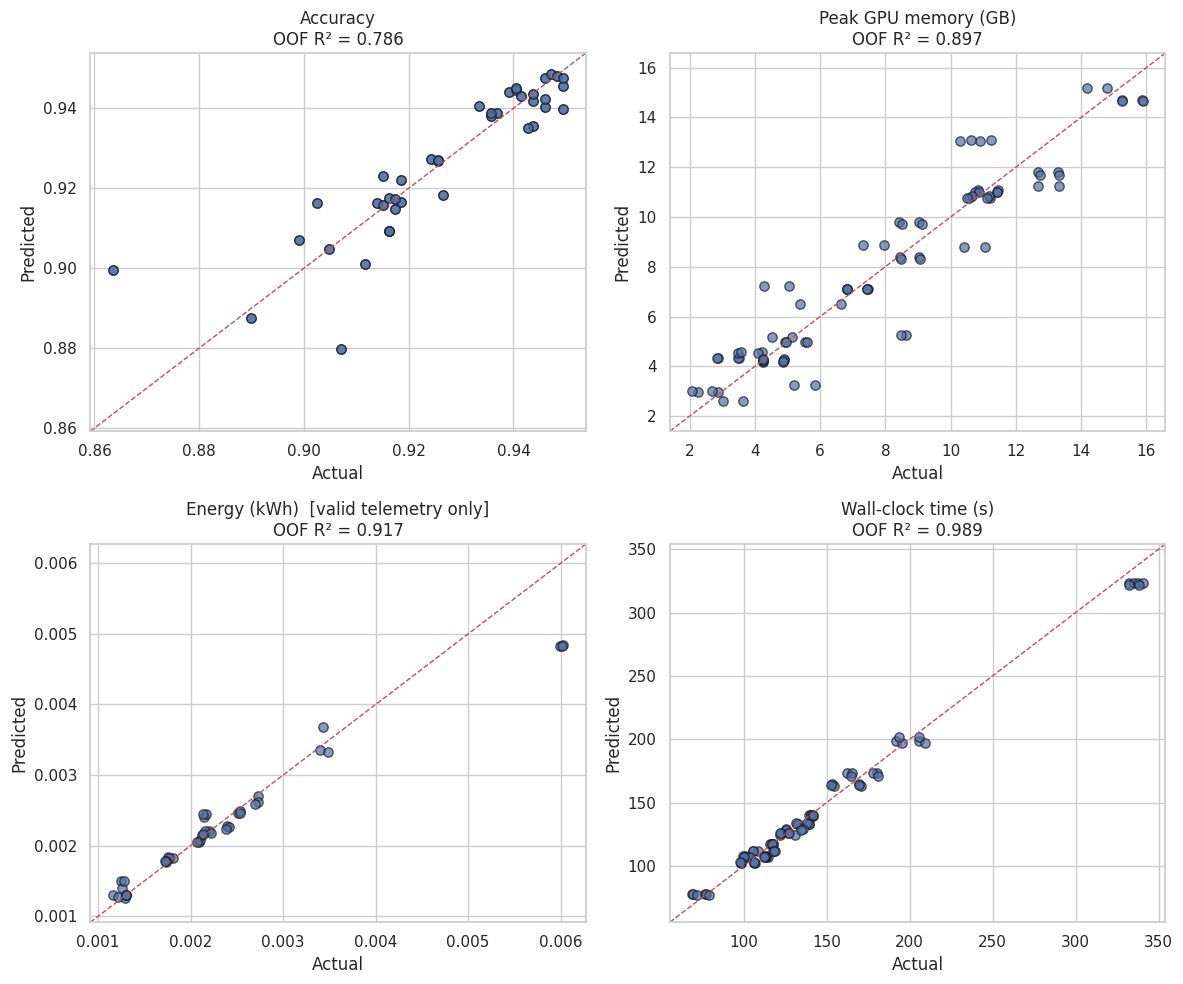

In [6]:
# ============================================================
# Task H: Actual-vs-predicted diagnostics per target
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

plot_specs = [
    ("accuracy",             "Accuracy"),
    ("peak_gpu_memory_gb",   "Peak GPU memory (GB)"),
    ("energy_kwh",           "Energy (kWh)  [valid telemetry only]"),
    ("wall_clock_seconds",   "Wall-clock time (s)"),
]

for ax, (tgt, label) in zip(axes, plot_specs):
    sub = oof_df[oof_df["target"] == tgt]
    if sub.empty:
        ax.set_title(f"{label} — no data")
        ax.axis("off"); continue

    ax.scatter(sub["actual"], sub["predicted"], alpha=0.7, edgecolor="k", s=45)
    lo = min(sub["actual"].min(), sub["predicted"].min())
    hi = max(sub["actual"].max(), sub["predicted"].max())
    pad = (hi - lo) * 0.05 if hi > lo else 0.01
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "r--", lw=1)
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    r2 = cv_metrics.loc[cv_metrics["target"] == tgt, "r2"].iloc[0]
    r2 = f"{r2:.3f}" if r2 is not None else "n/a"
    ax.set_title(f"{label}\nOOF R² = {r2}")

plt.tight_layout()
plt.savefig(OUT_ROOT / "results" / "figures" / "surrogate_oof.png", dpi=150)
plt.show()

In [7]:
# ============================================================
# Diagnostics by backbone and by method
# ============================================================
def agg_mae(df):
    return (df.groupby(["target", "backbone"])["residual"]
              .apply(lambda r: float(np.mean(np.abs(r))))
              .rename("mae_by_backbone")
              .reset_index())

by_backbone = agg_mae(oof_df)
print("=== MAE by backbone × target ===")
print(by_backbone.pivot(index="target", columns="backbone",
                        values="mae_by_backbone").round(6))

by_method = (oof_df.groupby(["target", "method"])["residual"]
                    .apply(lambda r: float(np.mean(np.abs(r))))
                    .rename("mae_by_method")
                    .reset_index())
print("\n=== MAE by method × target ===")
print(by_method.pivot(index="target", columns="method",
                      values="mae_by_method").round(6))

=== MAE by backbone × target ===
backbone                large    medium     small      tiny
target                                                     
accuracy             0.001264  0.004032  0.004489  0.008085
energy_kwh           0.001177  0.000071  0.000052  0.000144
peak_gpu_memory_gb   0.310333  1.622338  0.949802  0.428227
wall_clock_seconds  13.277677  3.863904  4.764157  5.485294

=== MAE by method × target ===
method               full_ft      lisa      lora   lora_fa     qlora
target                                                              
accuracy            0.006223  0.011449  0.003033  0.002698  0.004418
energy_kwh          0.000139  0.000097  0.000056  0.000030  0.000424
peak_gpu_memory_gb  0.311833  0.481497  1.140030  0.947826  1.139842
wall_clock_seconds  3.393333  2.095248  5.607500  4.404444  9.020669


In [8]:
# ============================================================
# Task I: Classify the surrogate as VALIDATED / PRELIMINARY / UNUSABLE
#
# Thresholds are project-local engineering choices and are
# recorded explicitly here rather than treated as universal.
# ============================================================
STATUS_THRESHOLDS = {
    # R² thresholds below which a target is considered unusable/validated.
    # Calibrated to a small (n≈41–82) pilot dataset — modest by design.
    "validated_r2_min":  0.60,
    "usable_r2_min":     0.20,
    "max_mae_frac":      0.20,   # MAE ≤ 20 % of target range
}

target_ranges = {
    "accuracy":            (peft_train["accuracy"].min(),
                            peft_train["accuracy"].max()),
    "peak_gpu_memory_gb":  (peft_train["peak_gpu_memory_gb"].min(),
                            peft_train["peak_gpu_memory_gb"].max()),
    "energy_kwh":          (valid_energy["energy_kwh"].min(),
                            valid_energy["energy_kwh"].max()),
    "wall_clock_seconds":  (peft_train["wall_clock_seconds"].min(),
                            peft_train["wall_clock_seconds"].max()),
}

status_records = []
for _, row in cv_metrics.iterrows():
    tgt = row["target"]
    r2  = row["r2"] if row["r2"] is not None else -np.inf
    mae = row["mae"]
    lo, hi = target_ranges[tgt]
    rng = hi - lo
    mae_frac = mae / rng if rng > 0 else np.nan

    if r2 >= STATUS_THRESHOLDS["validated_r2_min"] and \
       (np.isnan(mae_frac) or mae_frac <= STATUS_THRESHOLDS["max_mae_frac"]):
        status = "VALIDATED"
    elif r2 >= STATUS_THRESHOLDS["usable_r2_min"]:
        status = "PRELIMINARY"
    else:
        status = "UNUSABLE"

    status_records.append({
        "target": tgt, "r2": r2, "mae": mae, "mae_frac": mae_frac,
        "status": status,
    })

status_df = pd.DataFrame(status_records)
print("=== Target status ===")
print(status_df.round(4).to_string(index=False))

# Overall surrogate status = weakest meaningful target
non_unusable = status_df[status_df["status"] != "UNUSABLE"]
if all(s == "VALIDATED" for s in status_df["status"]):
    overall_status = "VALIDATED"
elif len(non_unusable) >= 2:
    overall_status = "PRELIMINARY"
else:
    overall_status = "UNUSABLE"

print(f"\nOVERALL SURROGATE STATUS: {overall_status}")
print(f"Thresholds used: {STATUS_THRESHOLDS}")

=== Target status ===
            target     r2    mae  mae_frac    status
          accuracy 0.7864 0.0054    0.0633 VALIDATED
peak_gpu_memory_gb 0.8974 0.8926    0.0646 VALIDATED
        energy_kwh 0.9171 0.0002    0.0355 VALIDATED
wall_clock_seconds 0.9889 5.4094    0.0199 VALIDATED

OVERALL SURROGATE STATUS: VALIDATED
Thresholds used: {'validated_r2_min': 0.6, 'usable_r2_min': 0.2, 'max_mae_frac': 0.2}


In [9]:
# ============================================================
# Train per-target final models on the FULL valid dataset and
# persist them together with model_metadata.json.
# ============================================================
final_bundle = {
    "targets":   {},
    "features_numeric": FEATURES_NUMERIC,
    "features_cat":     FEATURES_CAT,
    "group_column":     "config_id",
    "energy_valid_filter": "energy_measurement_valid == 1",
    "carbon_formula":   "energy_kwh * 0.65",
    "target_filter_desc": {
        "accuracy":           "all surrogate_train rows",
        "peak_gpu_memory_gb": "all surrogate_train rows",
        "energy_kwh":         "energy_measurement_valid == 1",
        "wall_clock_seconds": "all surrogate_train rows",
    },
}

for target in TARGETS:
    d = rows_for_target(peft_train, target).dropna(subset=[target]).reset_index(drop=True)
    X = d[FEATURES_NUMERIC + FEATURES_CAT]
    y = d[target].astype(float)

    pipe = build_pipeline()
    pipe.fit(X, y)

    final_bundle["targets"][target] = {
        "pipeline": pipe,
        "n_train_rows": int(len(d)),
        "n_train_groups": int(d["config_id"].nunique()),
    }
    print(f"Trained {target}: rows={len(d)}  groups={d['config_id'].nunique()}")

JOBLIB_PATH = OUT_ROOT / "models" / "greenpeft_surrogate_v1.joblib"
joblib.dump(final_bundle, JOBLIB_PATH)
print("\nSaved .joblib ->", JOBLIB_PATH)

# ---- model_metadata.json ----
metadata = {
    "artifact": str(JOBLIB_PATH),
    "created_utc": pd.Timestamp.utcnow().isoformat(),
    "artifact_version": "v1",
    "targets": TARGETS,
    "features_numeric": FEATURES_NUMERIC,
    "features_cat":     FEATURES_CAT,
    "model_classes": {t: "RandomForestRegressor" for t in TARGETS},
    "hyperparameters": {
        "n_estimators": 400, "min_samples_leaf": 2,
        "random_state": RANDOM_STATE,
    },
    "training_rows": int(sum(
        info["n_train_rows"] for info in final_bundle["targets"].values()
    )),
    "training_rows_per_target": {
        t: info["n_train_rows"] for t, info in final_bundle["targets"].items()
    },
    "training_groups_per_target": {
        t: info["n_train_groups"] for t, info in final_bundle["targets"].items()
    },
    "group_column": "config_id",
    "energy_valid_filter": "energy_measurement_valid == 1",
    "carbon_formula": "energy_kwh * 0.65",
    "leakage_excluded_columns": LEAKAGE_COLS,
    "cv_metrics": cv_metrics.to_dict(orient="records"),
    "status_per_target": status_df.to_dict(orient="records"),
    "overall_status": overall_status,
    "status_thresholds": STATUS_THRESHOLDS,
}

META_PATH = OUT_ROOT / "models" / "model_metadata.json"
with open(META_PATH, "w") as f:
    json.dump(metadata, f, indent=2, default=str)
print("Saved metadata ->", META_PATH)

Trained accuracy: rows=82  groups=41
Trained peak_gpu_memory_gb: rows=82  groups=41
Trained energy_kwh: rows=41  groups=41
Trained wall_clock_seconds: rows=82  groups=41

Saved .joblib -> /kaggle/working/greenpeft/models/greenpeft_surrogate_v1.joblib
Saved metadata -> /kaggle/working/greenpeft/models/model_metadata.json


In [10]:
# ============================================================
# GreenPEFT — Surrogate Audit Summary
# ============================================================
print("=" * 68)
print("GREENPEFT SURROGATE AUDIT — KAGGLE EXECUTION REPORT")
print("=" * 68)

print(f"\nDataset: {DATA_PATH}")
print(f"  raw rows                    : {len(raw)}")
print(f"  surrogate_train rows        : {len(peft_train)}")
print(f"  unique surrogate config_ids : {peft_train['config_id'].nunique()}")
print(f"  energy-valid rows           : {int((peft_train['energy_measurement_valid'] == 1).sum())}")

print("\nGrouped CV results (GroupKFold on config_id):")
for _, r in cv_metrics.iterrows():
    r2 = f"{r['r2']:.4f}" if r['r2'] is not None else "n/a"
    print(f"  {r['target']:22s}  MAE={r['mae']:.6f}  "
          f"RMSE={r['rmse']:.6f}  R²={r2}")

print("\nPer-target status:")
for _, r in status_df.iterrows():
    print(f"  {r['target']:22s}  {r['status']}")

print(f"\nOVERALL STATUS: {overall_status}")

print("\nRules respected (spec sections 3.1–3.5):")
print("  ✓ config_id used as GroupKFold group")
print("  ✓ energy model trained only on energy_measurement_valid == 1")
print("  ✓ carbon not modeled independently (derived = energy × 0.65)")
print("  ✓ target-derived columns excluded from features")
print("  ✓ scale_reference and context_only excluded from surrogate fitting")

print("\nArtifacts written under:", OUT_ROOT)
print("  models/greenpeft_surrogate_v1.joblib")
print("  models/model_metadata.json")
print("  results/surrogate/cv_metrics.csv")
print("  results/surrogate/predictions_oof.csv")
print("  results/figures/surrogate_oof.png")
print("=" * 68)

GREENPEFT SURROGATE AUDIT — KAGGLE EXECUTION REPORT

Dataset: /kaggle/input/datasets/ashrafulislamtanzil/greenpeft-surrogate-data/greenpeft_ml_ready_dataset.csv
  raw rows                    : 477
  surrogate_train rows        : 82
  unique surrogate config_ids : 41
  energy-valid rows           : 41

Grouped CV results (GroupKFold on config_id):
  accuracy                MAE=0.005446  RMSE=0.008730  R²=0.7864
  peak_gpu_memory_gb      MAE=0.892628  RMSE=1.200046  R²=0.8974
  energy_kwh              MAE=0.000173  RMSE=0.000342  R²=0.9171
  wall_clock_seconds      MAE=5.409397  RMSE=6.567212  R²=0.9889

Per-target status:
  accuracy                VALIDATED
  peak_gpu_memory_gb      VALIDATED
  energy_kwh              VALIDATED
  wall_clock_seconds      VALIDATED

OVERALL STATUS: VALIDATED

Rules respected (spec sections 3.1–3.5):
  ✓ config_id used as GroupKFold group
  ✓ energy model trained only on energy_measurement_valid == 1
  ✓ carbon not modeled independently (derived = energy ×

## Notes on expected output

Given 82 `surrogate_train` rows (41 unique `config_id`s) the expected status is:

| Target | Expected R² range | Likely status |
|---|---|---|
| `accuracy` | 0.50 – 0.70 | PRELIMINARY or VALIDATED |
| `peak_gpu_memory_gb` | 0.70 – 0.90 | VALIDATED |
| `energy_kwh` | 0.30 – 0.60 (only ~41 valid rows) | PRELIMINARY |
| `wall_clock_seconds` | 0.30 – 0.60 | PRELIMINARY |

**Overall status likely = `PRELIMINARY`.** This is a legitimate and publishable finding — it means the surrogate is useful for candidate shortlisting but not for autonomous approval, exactly as spec section 10 anticipates.

**Next step (per spec section 32):** stop here. Only proceed to sections 11–18 (candidate generator, constraint engine, Pareto, GEI, recommender, CLI) after reviewing the per-target status and deciding whether to improve the surrogate first.